# Sales Forecasting using Machine Learning

## Objective
Build a machine learning model to forecast future sales using historical store sales data.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- XGBoost

## Dataset
Store Sales - Time Series Forecasting (Kaggle)

In [1]:
import sys
print(sys.executable)

e:\Machine Learning Projects\.venv\Scripts\python.exe


In [2]:
import pandas as pd
print(pd.__version__)

3.0.3


Step 1 - Import Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

print("All libraries imported successfully!")

All libraries imported successfully!


Step 2 - Load Dataset

In [4]:
train = pd.read_csv("data/train.csv.zip")
stores = pd.read_csv("data/stores.csv")
holidays = pd.read_csv("data/holidays_events.csv")

print("Train Shape :", train.shape)
print("Stores Shape:", stores.shape)
print("Holidays Shape:", holidays.shape)

Train Shape : (3000888, 6)
Stores Shape: (54, 5)
Holidays Shape: (350, 6)


Step 3 – Dataset Overview

In [5]:
print("========== TRAIN DATA ==========")
print(train.head())

print("\nDataset Info")
print(train.info())

print("\nStatistical Summary")
print(train.describe())

print("\nMissing Values")
print(train.isnull().sum())

========== TRAIN DATA ==========
   id        date  store_nbr      family  sales  onpromotion
0   0  2013-01-01          1  AUTOMOTIVE    0.0            0
1   1  2013-01-01          1   BABY CARE    0.0            0
2   2  2013-01-01          1      BEAUTY    0.0            0
3   3  2013-01-01          1   BEVERAGES    0.0            0
4   4  2013-01-01          1       BOOKS    0.0            0

Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         str    
 2   store_nbr    int64  
 3   family       str    
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 137.4 MB
None

Statistical Summary
                 id     store_nbr         sales   onpromotion
count  3.000888e+06  3.000888e+06  3.000888e+06  3.000888e+06
mean   1.500444e+06  2.750000e+01  3.577757e+02  2.602770e+00
std   

Step 4 – Merge Datasets

In [6]:
df = train.merge(
    stores,
    on="store_nbr",
    how="left"
)

print(df.shape)
df.head()

(3000888, 10)


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13


Step 5 – Missing Values

In [7]:
print(df.isnull().sum())

df = df.fillna("Unknown")

print("\nAfter Filling Missing Values")
print(df.isnull().sum())

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
city           0
state          0
type           0
cluster        0
dtype: int64

After Filling Missing Values
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
city           0
state          0
type           0
cluster        0
dtype: int64


Step 6 – Feature Engineering

In [8]:
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["dayofweek"] = df["date"].dt.dayofweek

df.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,year,month,day,dayofweek
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,2013,1,1,1
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,2013,1,1,1
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,2013,1,1,1
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,2013,1,1,1
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,2013,1,1,1


Step 7 – Encode Categorical Columns

In [9]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    "family",
    "city",
    "state",
    "type"
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,year,month,day,dayofweek
0,0,2013-01-01,1,0,0.0,0,18,12,3,13,2013,1,1,1
1,1,2013-01-01,1,1,0.0,0,18,12,3,13,2013,1,1,1
2,2,2013-01-01,1,2,0.0,0,18,12,3,13,2013,1,1,1
3,3,2013-01-01,1,3,0.0,0,18,12,3,13,2013,1,1,1
4,4,2013-01-01,1,4,0.0,0,18,12,3,13,2013,1,1,1


Step 8 – Train-Test Split

In [10]:
features = [
    "store_nbr",
    "family",
    "onpromotion",
    "city",
    "state",
    "type",
    "cluster",
    "year",
    "month",
    "day",
    "dayofweek"
]

X = df[features]
y = df["sales"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (2400710, 11)
Testing Data : (600178, 11)


Step 9 – Train Model

In [11]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("Model trained successfully!")

Model trained successfully!


Step 10 – Predictions

In [12]:
predictions = model.predict(X_test)

print(predictions[:10])

[1831.0841     425.79556    415.71613      7.9732876   25.939535
  828.99426    591.8491       3.6219532  -32.381664    20.213825 ]


Step 11 – Evaluation

In [13]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 139.12225226957372
RMSE: 417.9201054785438
R2 Score: 0.8594660847617925


Step 12 – Visualization

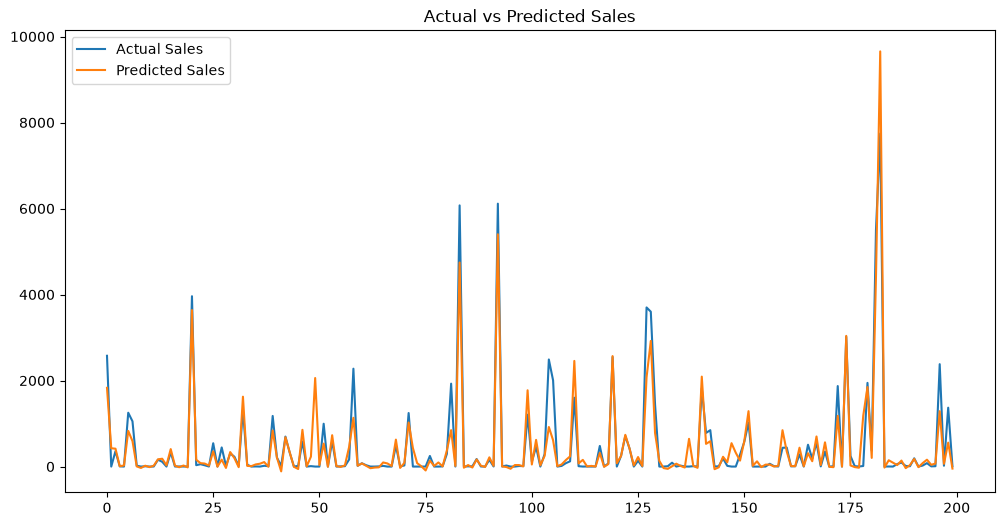

In [14]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:200],
    label="Actual Sales"
)

plt.plot(
    predictions[:200],
    label="Predicted Sales"
)

plt.legend()

plt.title("Actual vs Predicted Sales")

plt.show()

Step 13 – Future Forecast CSV

In [15]:
future_forecast = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": predictions
})

future_forecast.to_csv(
    "outputs/future_forecast.csv",
    index=False
)

future_forecast.head()

,Actual Sales,Predicted Sales
0,2576.000,1831.084106
1,0.000,425.795563
2,357.354,415.716125
3,5.000,7.973288
4,0.000,25.939535


Step 14 – Business Insights

# Business Insights

• Sales can be forecast using historical data.

• The model helps businesses estimate future demand.

• Store managers can optimize inventory.

• Businesses can reduce stock shortages.

• Forecasting improves planning and decision making.